<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.878 · Trabajo Final del Máster · Área 1 · Aula 1</p>
<p style="margin: 0; text-align:right;">20241 - Máster universitario en Ciencias de datos (<i>Data science</i>)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicaciones</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
    <strong>Estudiante:</strong> James Eward Humberstone Morales
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <p>El horizonte de predicción para cada clúster sea definido en función del ciclo de aprovisionamiento, entendido como la suma entre el intervalo entre pedidos y el tiempo de entrega (lead time). Se utilizó el valor de la mediana por clúster como estimación operativa, buscando un equilibrio entre la precisión y la aplicabilidad logística.</p>
</div>

In [1]:
!pip install pmdarima scikit_posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.0 MB/s eta 0:00:00


In [2]:
# Carga de librerías
import pandas as pd
import numpy as np
import random
import tensorflow as tf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,  mean_absolute_error
from keras.models import Sequential, save_model, load_model
from keras.layers import LSTM, Dense, Input
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
import keras_tuner as kt
from sklearn.model_selection import train_test_split
import joblib
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import scipy.stats as stats 
from scipy.stats import shapiro, levene, kruskal, kstest, norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
from scipy.optimize import minimize_scalar
import scikit_posthocs as sp


2025-04-28 03:33:15.973859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745811196.175292      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745811196.229928      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
df_regulares = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

# 1. Prepraración de los datos

In [4]:
# -----------------------------
# Establecer semilla para reproducibilidad
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
# Crear one-hot encoding
dummies_cluster = pd.get_dummies(df_regulares['cluster_kmeans'], prefix='cluster')
dummies_day = pd.get_dummies(df_regulares['day_of_week'], prefix='dow')
df_regulares = pd.concat([df_regulares, dummies_cluster, dummies_day], axis=1)
df_regulaesr = df_regulares.drop(['cluster_kmeans', 'day_of_week'], axis=1)

columnas_onehot = list(dummies_cluster.columns) + list(dummies_day.columns)

target = "udsVenta"
exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion',
    'week_of_year', 'week_of_month', 'median_venta',
    'cv', 'outlier_rate', 'aprovisionamiento'
] + columnas_onehot

columnas_modelo = [target] + exogenas
n_lags = 30

In [6]:
df_regulares.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654408 entries, 0 to 654407
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   producto           654408 non-null  int64         
 1   idSecuencia        654408 non-null  datetime64[ns]
 2   bolOpen            654408 non-null  int64         
 3   bolHoliday         654408 non-null  int64         
 4   year               654408 non-null  int64         
 5   month              654408 non-null  int64         
 6   day                654408 non-null  int64         
 7   day_of_week        654408 non-null  int64         
 8   week_of_year       654408 non-null  int64         
 9   week_of_month      654408 non-null  int64         
 10  bolPromotion       654408 non-null  int64         
 11  udsVenta           654408 non-null  int64         
 12  median_venta       654408 non-null  int64         
 13  cv                 654408 non-null  float64 

In [7]:
# -----------------------------
# GENERAR SECUENCIAS MULTISERIE
# -----------------------------
X_total = []
y_total = []
productos_validos = 0

for producto_id, df_prod in df_regulares.groupby("producto"):
    df_prod = df_prod.sort_values("idSecuencia")
    
    if len(df_prod) <= n_lags:
        continue  # Saltar si la serie es muy corta

    datos = df_prod[columnas_modelo].copy()

    # Asegurar que aprovisionamiento es constante (replicado si hace falta)
    if "aprovisionamiento" in datos.columns:
        aprov_valor = datos["aprovisionamiento"].iloc[0]
        datos["aprovisionamiento"] = aprov_valor

    # Escalar individualmente
    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    for i in range(n_lags, len(datos_scaled)):
        X_total.append(datos_scaled[i - n_lags:i])
        y_total.append(datos_scaled[i][0])  # udsVenta

    productos_validos += 1

# -----------------------------
# CONVERTIR Y GUARDAR
# -----------------------------
X_total = np.array(X_total)
y_total = np.array(y_total)

np.save("X_lstm_multiserie.npy", X_total)
np.save("y_lstm_multiserie.npy", y_total)

# Guardar columnas usadas
joblib.dump(columnas_modelo, "columnas_modelo_lstm.pkl")

print(f"Dataset generado con éxito")
print(f"Productos válidos: {productos_validos}")
print(f"X shape: {X_total.shape} | y shape: {y_total.shape}")

Dataset generado con éxito
Productos válidos: 894
X shape: (627588, 30, 22) | y shape: (627588,)


# 2. Generar red LSTM

In [8]:
# -----------------------------
# CARGAR DATOS
# -----------------------------
X = np.load("/kaggle/working/X_lstm_multiserie.npy")
y = np.load("/kaggle/working/y_lstm_multiserie.npy")


In [9]:
# -----------------------------
# CONSTRUIR MODELO PARA TUNING
# -----------------------------
def construir_modelo_lstm(hp):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))  
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3])
        ),
        loss='mse'
    )
    return model

In [10]:
# -----------------------------
# CONFIGURAR KERASTUNER
# -----------------------------
tuner = kt.RandomSearch(
    construir_modelo_lstm,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_lstm_general',
    project_name='lstm_multiserie0',
    seed=SEED
)


I0000 00:00:1745811321.001984      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [11]:
# -----------------------------
# ENTRENAMIENTO CON VALIDACIÓN
# -----------------------------
def get_batch_size(hp):
    return hp.Choice('batch_size', values=[64, 128])

tuner.search(
    X, y,
    epochs=30,
    batch_size=get_batch_size(tuner.oracle.hyperparameters),
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Trial 5 Complete [00h 11m 29s]
val_loss: 0.022336503490805626

Best val_loss So Far: 0.022266866639256477
Total elapsed time: 00h 57m 07s


In [12]:
# -----------------------------
# Obtener el mejor modelo y entrenar
# -----------------------------
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.fit(X, y, epochs=30, batch_size=best_hp.get('batch_size'), verbose=1)

Epoch 1/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.0324
Epoch 2/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0309
Epoch 3/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0308
Epoch 4/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0307
Epoch 5/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0306
Epoch 6/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0305
Epoch 7/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0304
Epoch 8/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0304
Epoch 9/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0303
Epoch 10/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0303
Epoch 11/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0303
Epoch 12/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0302
Epoch 13/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0302
Epoch 14/30
4904/4904 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0301
Epoch 15/30
490

In [13]:
# Guardar modelo y parámetros
save_model(best_model, "modelo_lstm_general.h5", include_optimizer=False)
joblib.dump(best_hp.values, "hiperparametros_lstm_general.pkl")

print("Entrenamiento completado. Modelo y parámetros guardados.")

Entrenamiento completado. Modelo y parámetros guardados.


# 2.1. Calcular la predicción LSTM 

In [14]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
columnas_modelo = joblib.load("/kaggle/working/columnas_modelo_lstm.pkl")
target = columnas_modelo[0]
exogenas = columnas_modelo[1:]
n_lags = 30

In [15]:
# -----------------------------
# CARGAR MODELO LSTM GENERAL
# -----------------------------
modelo = load_model("/kaggle/working/modelo_lstm_general.h5", compile=False)

In [16]:
# -----------------------------
# FUNCIONES
# -----------------------------
def preparar_X_pred(df_producto, columnas, n_lags):
    df_producto = df_producto.sort_values("idSecuencia")
    datos = df_producto[columnas].copy()

    # Replicar aprovisionamiento si es constante
    if "aprovisionamiento" in datos.columns:
        datos["aprovisionamiento"] = datos["aprovisionamiento"].iloc[0]

    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    if len(datos_scaled) <= n_lags:
        return None, None, None, None

    X_pred = [datos_scaled[i - n_lags:i] for i in range(n_lags, len(datos_scaled))]
    fechas = df_producto["idSecuencia"].iloc[n_lags:].values
    y_real = df_producto[target].iloc[n_lags:].values

    return np.array(X_pred), fechas, y_real, scaler

def desescalar_predicciones(pred_scaled, scaler, n_exogenas):
    datos_completos = np.concatenate(
        [pred_scaled, np.zeros((len(pred_scaled), n_exogenas))], axis=1
    )
    return scaler.inverse_transform(datos_completos)[:, 0]

In [17]:
# -----------------------------
# PREDICCIÓN PARA TODAS LAS SERIES
# -----------------------------

# Inicializar timer y barra de progreso
inicio = time.time()
productos = df_regulares['producto'].unique()

resultados = []

for producto_id, df_producto in tqdm(df_regulares.groupby("producto")):
    X_pred, fechas, y_real, scaler_local = preparar_X_pred(df_producto, columnas_modelo, n_lags)
    if X_pred is None:
        continue

    y_pred_scaled = modelo.predict(X_pred, verbose=0)
    y_pred = desescalar_predicciones(y_pred_scaled, scaler_local, len(exogenas))

    df_resultado = pd.DataFrame({
        'producto': producto_id,
        'fecha': fechas,
        'valor_real': y_real,
        'valor_predicho': y_pred,
        'metodo': 'LSTM',
        'kmeans': -1
    })
    resultados.append(df_resultado)

fin = time.time()
tiempo_total = fin - inicio
print(f"\n Predicciones finalizadas en {tiempo_total:.2f} segundos.")

100%|██████████| 894/894 [01:44<00:00,  8.52it/s]


 Predicciones finalizadas en 104.92 segundos.


In [18]:
# Concatenar resultados y exportar
df_predicciones_lstm_general = pd.concat(resultados, ignore_index=True)
df_predicciones_lstm_general.to_csv("predicciones_lstm_general.csv", index=False)

# 2.2 Visualizaciones

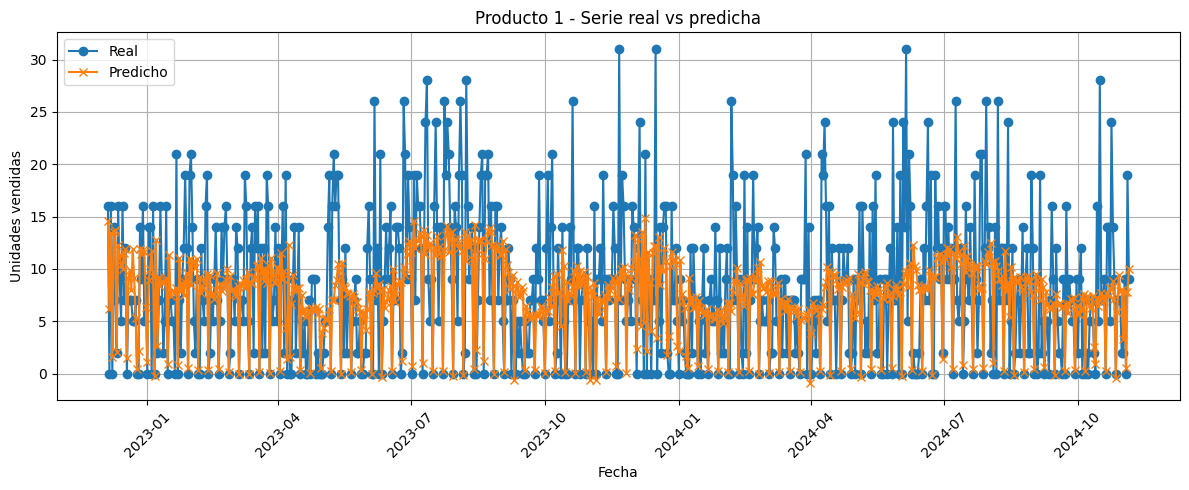

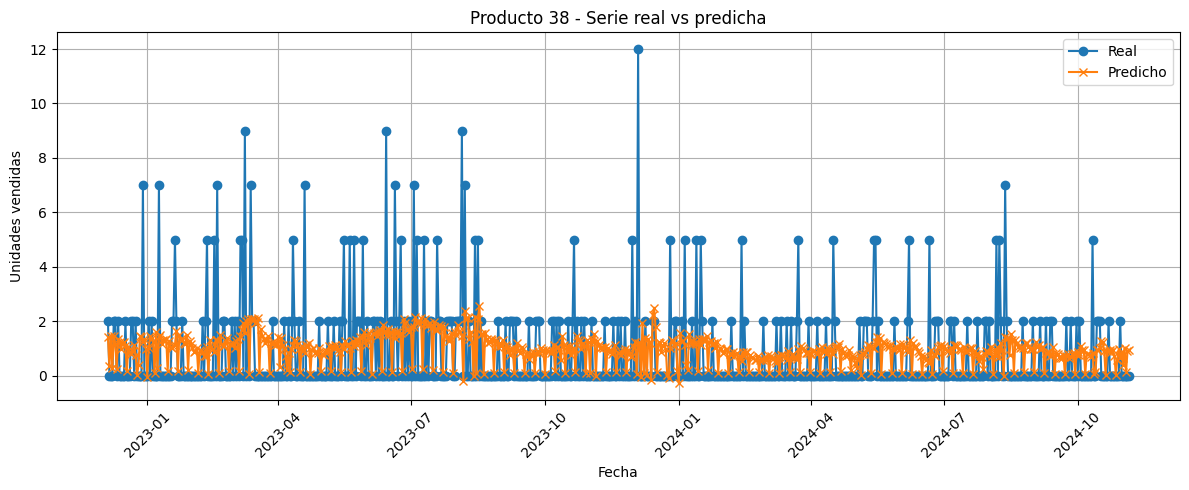

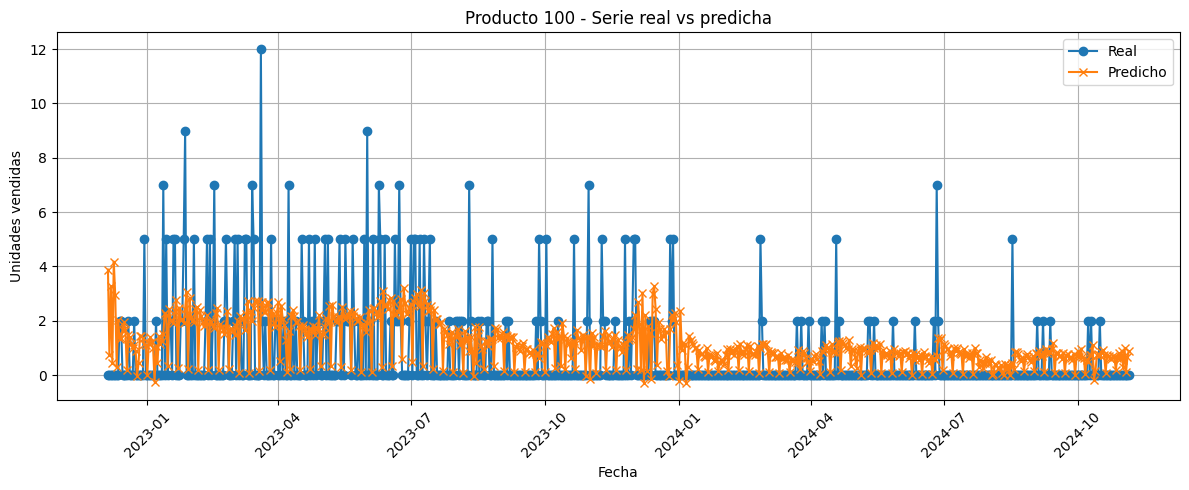

In [19]:
productos_ejemplo = [1, 38, 100]

for producto_id in productos_ejemplo:
    df_prod = df_predicciones_lstm_general[df_predicciones_lstm_general['producto'] == producto_id]
    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_producto_{producto_id}.png")
    plt.show()

In [20]:
# Calcular RMSE por producto
rmse_por_producto = (
    df_predicciones_lstm_general[['producto', 'valor_real', 'valor_predicho']]
    .groupby("producto")[['valor_real', 'valor_predicho']]
    .apply(lambda g: np.sqrt(np.mean((g['valor_real'] - g['valor_predicho']) ** 2)))
    .reset_index(name="RMSE")
)

print(rmse_por_producto.describe())

          producto        RMSE
count   894.000000  894.000000
mean    502.115213    2.096029
std     291.391762    1.197827
min       1.000000    0.724814
25%     247.250000    1.582606
50%     506.500000    1.894306
75%     753.750000    2.415084
max    1000.000000   27.990206


In [21]:
# RMSE global
rmse_global = np.sqrt(np.mean((df_predicciones_lstm_general['valor_real'] - df_predicciones_lstm_general['valor_predicho']) ** 2))
print(f"RMSE global del modelo LSTM generalizado: {rmse_global:.4f}")

RMSE global del modelo LSTM generalizado: 2.4138


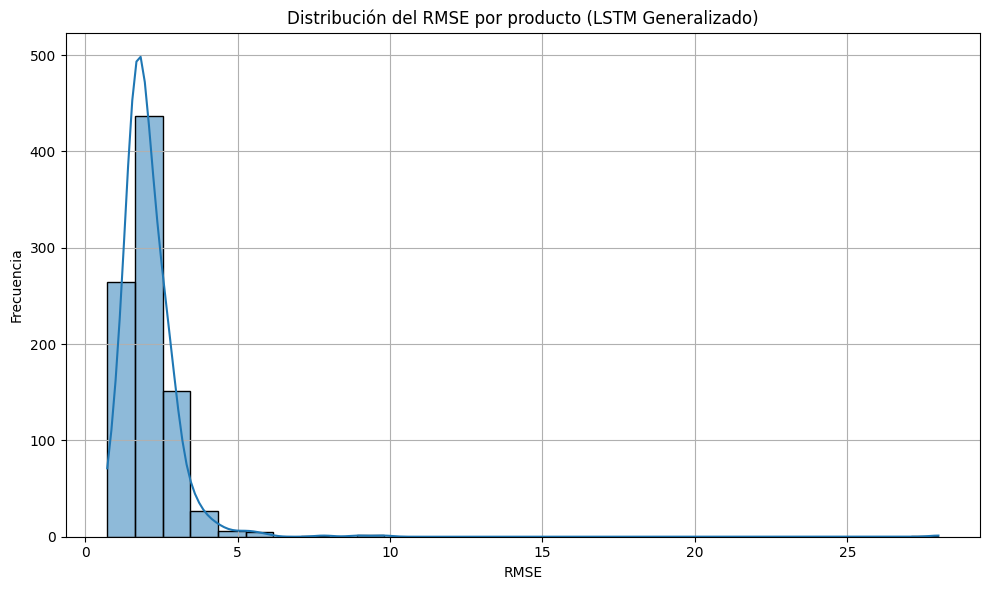

In [22]:
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(10, 6))
sns.histplot(rmse_por_producto['RMSE'], bins=30, kde=True)
plt.title("Distribución del RMSE por producto (LSTM Generalizado)")
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.savefig("histograma_rmse_lstm.png")
plt.show()

# 3. Aplicar el modelo ARIMA

In [23]:
df_regulares = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

In [24]:
df_regulares.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654408 entries, 0 to 654407
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   producto           654408 non-null  int64         
 1   idSecuencia        654408 non-null  datetime64[ns]
 2   bolOpen            654408 non-null  int64         
 3   bolHoliday         654408 non-null  int64         
 4   year               654408 non-null  int64         
 5   month              654408 non-null  int64         
 6   day                654408 non-null  int64         
 7   day_of_week        654408 non-null  int64         
 8   week_of_year       654408 non-null  int64         
 9   week_of_month      654408 non-null  int64         
 10  bolPromotion       654408 non-null  int64         
 11  udsVenta           654408 non-null  int64         
 12  median_venta       654408 non-null  int64         
 13  cv                 654408 non-null  float64 

In [25]:
# -----------------------------
# Configuración
# -----------------------------
n_test = 30  # horizonte de predicción
col_serie = "udsVenta"

In [26]:
# -----------------------------
# Función para ajustar ARIMA por producto
# -----------------------------
def ajustar_arima_producto(df_producto, col_serie="udsVenta", n_test=30):
    df_producto = df_producto.sort_values("idSecuencia")
    serie = df_producto[col_serie].values

    if len(serie) <= n_test + 10:
        return None  # muy corta para entrenar

    try:
        # 1. Determinar orden ARIMA automáticamente
        modelo_auto = auto_arima(serie[:-n_test], seasonal=False,
                                 error_action='ignore', suppress_warnings=True,
                                 max_p=5, max_q=5, max_d=2, stepwise=True)
        orden = modelo_auto.order

        # 2. Ajustar ARIMA final
        modelo = ARIMA(serie[:-n_test], order=orden)
        modelo_fit = modelo.fit()

        # 3. Predecir y calcular residuos
        y_pred = modelo_fit.predict(start=len(serie) - n_test, end=len(serie) - 1)
        y_real = serie[-n_test:]
        residuos = y_real - y_pred

        return {
            "orden": orden,
            "y_pred": y_pred,
            "residuos": residuos,
            "y_real": y_real,
            "modelo_fit": modelo_fit
        }

    except Exception as e:
        print(f"Error en producto {df_producto['producto'].iloc[0]}: {e}")
        return None

In [27]:
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters")
warnings.simplefilter("ignore", ConvergenceWarning)

In [28]:
# -----------------------------
# Aplicar a todos los productos regulares
# -----------------------------

# Inicializar timer y barra de progreso
inicio = time.time()
productos = df_regulares['producto'].unique()

resultados_arima = {}
for producto_id, df_prod in tqdm(df_regulares.groupby("producto")):
    resultado = ajustar_arima_producto(df_prod, col_serie=col_serie, n_test=n_test)
    if resultado is not None:
        resultados_arima[producto_id] = resultado

fin = time.time()
tiempo_total = fin - inicio
print(f"\n Predicciones finalizadas en {tiempo_total:.2f} segundos.")

100%|██████████| 894/894 [1:31:23<00:00,  6.13s/it]


 Predicciones finalizadas en 5483.90 segundos.


In [29]:
# -----------------------------
# Guardar resultados
# -----------------------------
joblib.dump(resultados_arima, "resultados_arima.pkl")
print(f"ARIMA ajustado para {len(resultados_arima)} productos.")


ARIMA ajustado para 894 productos.


In [30]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima.pkl")

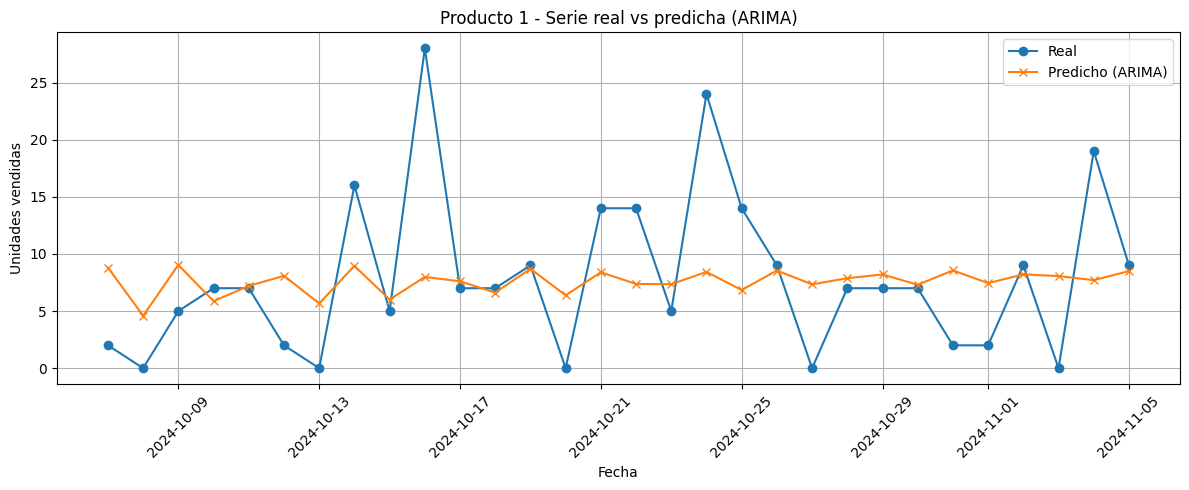

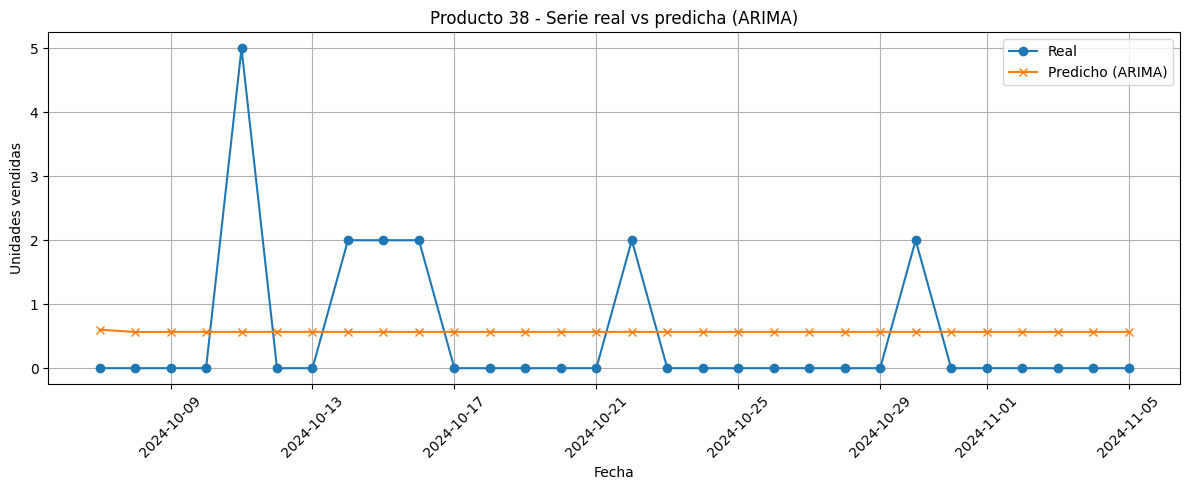

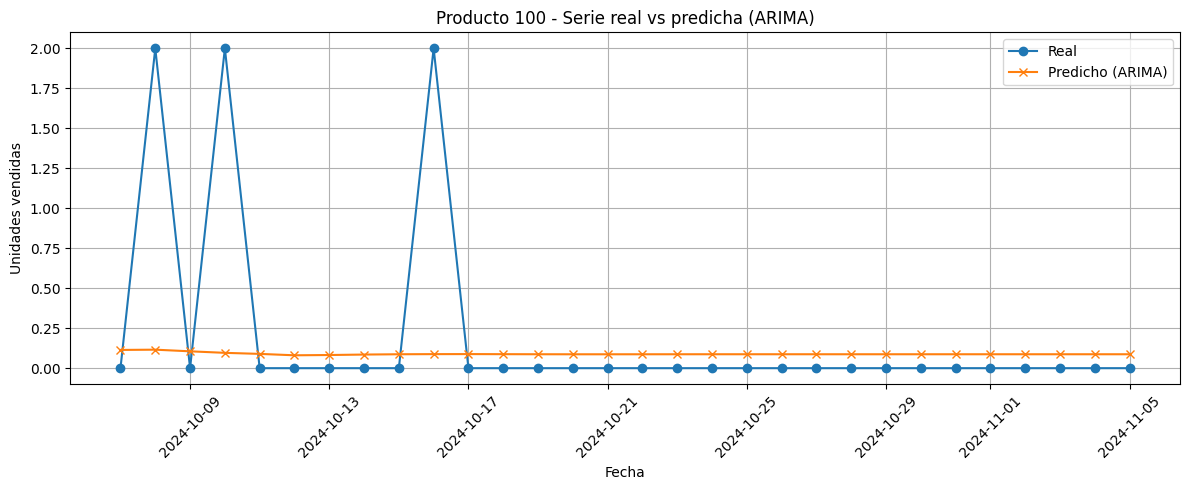

In [31]:
productos_ejemplo = [1, 38, 100] 

for producto_id in productos_ejemplo:
    resultado = resultados_arima[producto_id]
    
    y_real = resultado["y_real"]
    y_pred = resultado["y_pred"]
    
    
    # Verificar si hay datos del producto en el DataFrame
    df_producto = df_regulares[df_regulares['producto'] == producto_id].copy()

    if not df_producto.empty:
        fechas_disponibles = df_producto['idSecuencia'].reset_index(drop=True)
        # Ajustamos el número de fechas a la longitud de y_real
        if len(fechas_disponibles) >= len(y_real):
            fechas = fechas_disponibles.iloc[-len(y_real):].reset_index(drop=True)
        else:
            raise ValueError(f"El número de fechas disponibles ({len(fechas_disponibles)}) es menor que la longitud de y_real ({len(y_real)}) para el producto {producto_id}")
    else:
        raise ValueError(f"No se encontraron datos en df_regulares para el producto {producto_id}")

    # Crear DataFrame para trazado
    df_plot = pd.DataFrame({
        'fecha': fechas,
        'Real': y_real,
        'Predicho': y_pred
    })

    # Gráfico
    plt.figure(figsize=(12, 5))
    plt.plot(df_plot['fecha'], df_plot['Real'], label='Real', marker='o')
    plt.plot(df_plot['fecha'], df_plot['Predicho'], label='Predicho (ARIMA)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (ARIMA)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_arima_producto_{producto_id}.png")
    plt.show()

# 4. Modelo híbrido paralelo

In [32]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima.pkl")

In [33]:
# --- Cargar base original para obtener fechas ---
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

# Asegurarnos que las fechas estén ordenadas por producto y por secuencia
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [34]:
# --- Cargar predicciones LSTM ---
df_lstm = pd.read_csv("/kaggle/working/predicciones_lstm_general.csv")

In [35]:
# Crear diccionario para fechas por producto (últimos N puntos según cada serie ARIMA)
fechas_por_producto = {}
for producto_id in resultados_arima.keys():
    n_puntos = len(resultados_arima[producto_id]["y_real"])
    fechas = df_base[df_base["producto"] == producto_id]["idSecuencia"].iloc[-n_puntos:].reset_index(drop=True)
    fechas_por_producto[producto_id] = fechas


In [36]:
# --- Calcular combinación ponderada ARIMA + LSTM ---
resultados_paralelo_ponderado = []

for producto_id in resultados_arima.keys():
    arima_data = resultados_arima[producto_id]
    y_pred_arima = np.array(arima_data["y_pred"])
    y_real = np.array(arima_data["y_real"])

    # Obtener fechas correspondientes
    fechas = fechas_por_producto[producto_id]

    # LSTM: filtrar y alinear
    df_lstm_prod = df_lstm[df_lstm['producto'] == producto_id].copy()
    if len(df_lstm_prod) >= len(y_pred_arima):
        y_pred_lstm = df_lstm_prod['valor_predicho'].values[-len(y_pred_arima):]
        y_real_lstm = df_lstm_prod['valor_real'].values[-len(y_pred_arima):]

        # Verificación (opcional)
        if not np.allclose(y_real, y_real_lstm):
            print(f"[!] Warning: diferencias en y_real para producto {producto_id}, se usará y_real de ARIMA.")

        # --- Optimizar peso ---
        def calcular_rmse_ponderado(w_arima, y_arima, y_lstm, y_real):
            y_comb = w_arima * y_arima + (1 - w_arima) * y_lstm
            return mean_squared_error(y_real, y_comb, squared=False)

        resultado = minimize_scalar(
            calcular_rmse_ponderado,
            bounds=(0, 1),
            args=(y_pred_arima, y_pred_lstm, y_real),
            method='bounded'
        )

        w_optimo = resultado.x
        rmse_optimo = resultado.fun
        y_comb = w_optimo * y_pred_arima + (1 - w_optimo) * y_pred_lstm
        mae = mean_absolute_error(y_real, y_comb)
        mape = np.mean(np.abs((y_real - y_comb) / np.maximum(y_real, 1))) * 100

        # Guardar resultados
        for fecha, real, pred in zip(fechas, y_real, y_comb):
            resultados_paralelo_ponderado.append({
                "producto": producto_id,
                "fecha": fecha,
                "valor_real": real,
                "valor_predicho": pred,
                "w_arima": round(w_optimo, 3),
                "w_lstm": round(1 - w_optimo, 3),
                "rmse": rmse_optimo,
                "mae": mae,
                "mape": mape,
                "modelo": "paralelo_ponderado"
            })
    else:
        print(f"LSTM no tiene suficientes datos para producto {producto_id}")

# Convertir a DataFrame
df_resultados_paralelo_ponderado = pd.DataFrame(resultados_paralelo_ponderado)

In [37]:
df_resultados_paralelo_ponderado.head()

,producto,fecha,valor_real,valor_predicho,w_arima,w_lstm,rmse,mae,mape,modelo
0,1,2024-10-07,2,7.594968,0.155,0.845,6.2076,3.993575,87.885091,paralelo_ponderado
1,1,2024-10-08,0,6.887484,0.155,0.845,6.2076,3.993575,87.885091,paralelo_ponderado
2,1,2024-10-09,5,6.923742,0.155,0.845,6.2076,3.993575,87.885091,paralelo_ponderado
3,1,2024-10-10,7,6.185532,0.155,0.845,6.2076,3.993575,87.885091,paralelo_ponderado
4,1,2024-10-11,7,7.401541,0.155,0.845,6.2076,3.993575,87.885091,paralelo_ponderado


In [38]:
df_resultados_paralelo_ponderado.to_csv("predicciones_ponderado.csv", index=False)

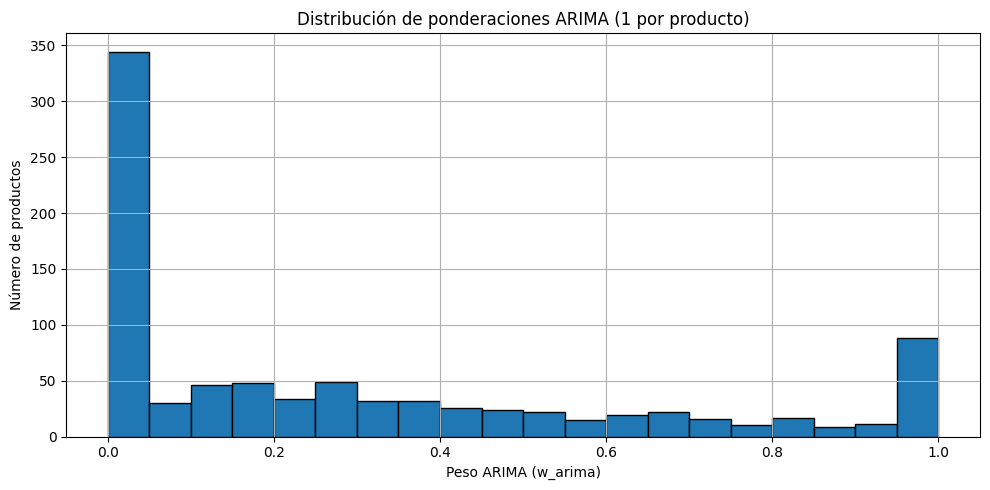

In [39]:
df_pesos_unicos = df_resultados_paralelo_ponderado.drop_duplicates(subset="producto")


plt.figure(figsize=(10, 5))
plt.hist(df_pesos_unicos["w_arima"], bins=20, edgecolor='black')
plt.title("Distribución de ponderaciones ARIMA (1 por producto)")
plt.xlabel("Peso ARIMA (w_arima)")
plt.ylabel("Número de productos")
plt.grid(True)
plt.tight_layout()
plt.show()

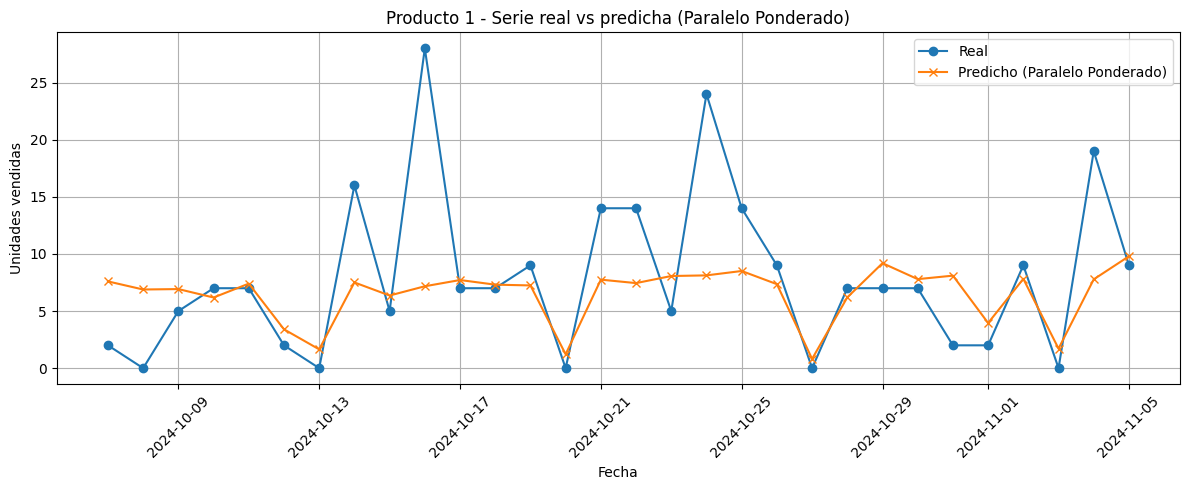

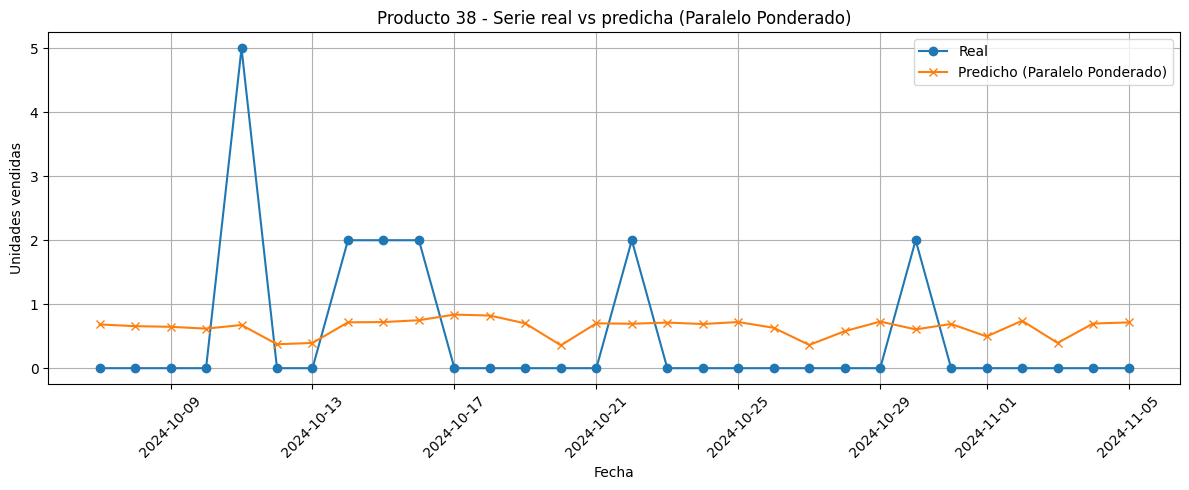

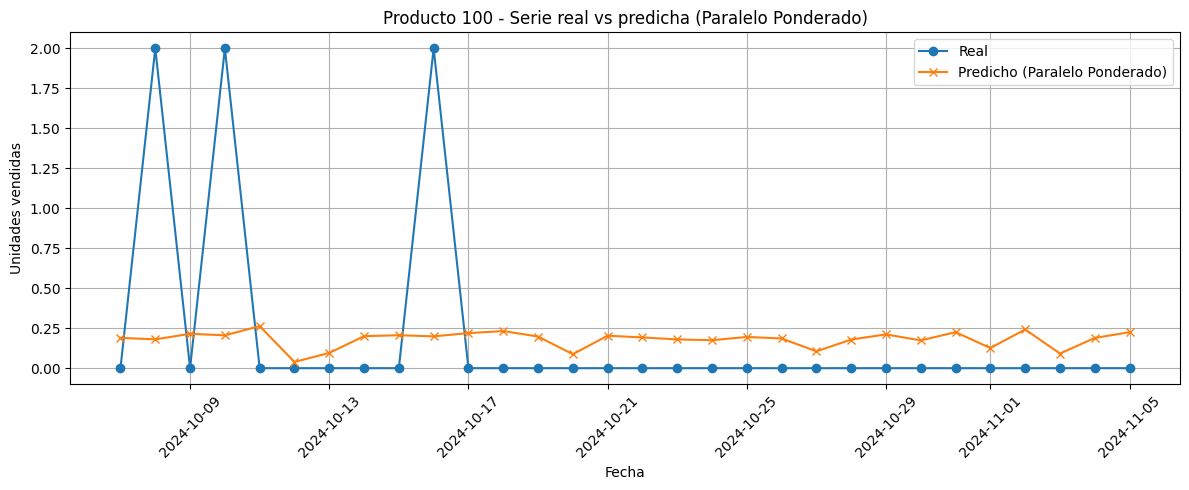

In [40]:
productos_ejemplo = [1, 38, 100] 

for producto_id in productos_ejemplo:
    df_prod = df_resultados_paralelo_ponderado[df_resultados_paralelo_ponderado['producto'] == producto_id]
    
    if df_prod.empty:
        print(f"No se encontraron datos para el producto {producto_id}")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho (Paralelo Ponderado)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (Paralelo Ponderado)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_paralelo_ponderado_producto_{producto_id}.png")
    plt.show()


 # 5. Modelo Naive (referencia)

In [41]:
# -----------------------------
# CARGAR BASE Y RESULTADOS ARIMA
# -----------------------------
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [42]:
# -----------------------------
# GENERAR MODELO NAIVE
# -----------------------------
resultados_naive = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    
    if len(y_real) < 2:
        continue  # no se puede generar naive

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    fechas = df_prod["idSecuencia"].values[1:]  # desde la 2da fecha
    y_real_recortado = y_real[1:]               # valores reales desde t=2
    y_pred_naive = y_real[:-1]                  # valores anteriores como predicción

    for i in range(len(y_pred_naive)):
        resultados_naive.append({
            "producto": producto_id,
            "fecha": fechas[i],
            "valor_real": y_real_recortado[i],
            "valor_predicho": y_pred_naive[i],
            "modelo": "naive"
        })

In [43]:
# -----------------------------
# CREAR DATAFRAME Y MÉTRICAS
# -----------------------------
df_resultados_naive = pd.DataFrame(resultados_naive)

# Calcular métricas por producto
metricas = df_resultados_naive.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

df_resultados_naive = df_resultados_naive.merge(metricas, on="producto", how="left")

In [44]:
# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
df_resultados_naive.to_csv("predicciones_naive.csv", index=False)
print("Predicciones del modelo naive generadas")


Predicciones del modelo naive generadas


# 6. Mejor modelo

In [45]:
# -----------------------------
# CARGAR ARCHIVOS
# -----------------------------
df_naive = pd.read_csv("/kaggle/working/predicciones_naive.csv")
df_paralelo = pd.read_csv("/kaggle/working/predicciones_ponderado.csv")

In [46]:
# -----------------------------
# FILTRAR 30 ÚLTIMOS PUNTOS DE CADA MODELO
# -----------------------------
def filtrar_ultimos_30(df, nombre_modelo):
    df = df.copy()
    df = df.sort_values(["producto", "fecha"])
    df["rank"] = df.groupby("producto")["fecha"].rank(method="first", ascending=False)
    df = df[df["rank"] <= 30].copy()
    df["modelo"] = nombre_modelo
    return df.drop(columns=["rank"])

df_naive = filtrar_ultimos_30(df_naive, "naive")
df_paralelo = filtrar_ultimos_30(df_paralelo, "paralelo")


In [47]:
# -----------------------------
# UNIFICAR ESTRUCTURA
# -----------------------------
def estandarizar_columnas(df, nombre_modelo):
    df = df.copy()
    df["modelo"] = nombre_modelo
    columnas_requeridas = ["producto", "fecha", "valor_real", "valor_predicho", "modelo", "rmse", "mae", "mape"]
    for col in ["rmse", "mae", "mape"]:
        if col not in df.columns:
            df[col] = None  # se calcularán después si no existen
    return df[columnas_requeridas]

df_naive = estandarizar_columnas(df_naive, "naive")
df_paralelo = estandarizar_columnas(df_paralelo, "paralelo")

In [48]:
# -----------------------------
# UNIR TODOS LOS MODELOS
# -----------------------------
df_comparacion = pd.concat([
    df_naive,
    df_paralelo
], ignore_index=True)

# -----------------------------
# GUARDAR ARCHIVO FINAL
# -----------------------------
df_comparacion.to_csv("resultados_comparacion_modelos.csv", index=False)
print("Archivo unificado generado")

Archivo unificado generado


In [49]:
# -----------------------------
# IDENTIFICAR EL MEJOR MODELO POR PRODUCTO (basado en menor RMSE)
# -----------------------------
# Obtener el modelo con menor RMSE por producto
mejores_modelos = df_comparacion.groupby("producto")["rmse"].idxmin()
df_mejores = df_comparacion.loc[mejores_modelos, ["producto", "modelo", "rmse"]].reset_index(drop=True)

# -----------------------------
# UNIR PARA TOMAR LA PREDICCIÓN COMPLETA DE ESE MODELO
# -----------------------------
df_pred_mejor = pd.merge(
    df_comparacion,
    df_mejores,
    on=["producto", "modelo", "rmse"],
    how="inner"
)[["producto", "fecha", "valor_real", "valor_predicho", "rmse", "modelo"]]

# Renombrar columna para claridad
df_pred_mejor.rename(columns={"valor_predicho": "mejor_pronostico"}, inplace=True)

In [50]:
df_pred_mejor.tail()

,producto,fecha,valor_real,mejor_pronostico,rmse,modelo
26774,1000,2024-11-01,0,0.699661,2.142319,paralelo
26775,1000,2024-11-02,0,1.306760,2.142319,paralelo
26776,1000,2024-11-03,0,0.561846,2.142319,paralelo
26777,1000,2024-11-04,7,1.222970,2.142319,paralelo
26778,1000,2024-11-05,2,1.421698,2.142319,paralelo


In [51]:
# -----------------------------
# GUARDAR RESULTADO
# -----------------------------
df_pred_mejor.to_csv("mejor_pronostico_por_producto.csv", index=False)
print("Archivo generado con las mejores predicciones por producto.")


Archivo generado con las mejores predicciones por producto.


In [52]:
# -----------------------------
# ELIMINAR DUPLICADOS POR PRODUCTO (una fila por serie)
# -----------------------------
df_modelo_unico = df_pred_mejor.drop_duplicates(subset=["producto"])

# -----------------------------
# CALCULAR FRECUENCIA PORCENTUAL POR MODELO
# -----------------------------
frecuencia = (
    df_modelo_unico["modelo"]
    .value_counts(normalize=True)
    .rename("frecuencia_porcentual")
    .reset_index()
    .rename(columns={"index": "modelo"})
)

frecuencia["frecuencia_porcentual"] = frecuencia["frecuencia_porcentual"] * 100

frecuencia

,modelo,frecuencia_porcentual
0,paralelo,95.41387
1,naive,4.58613


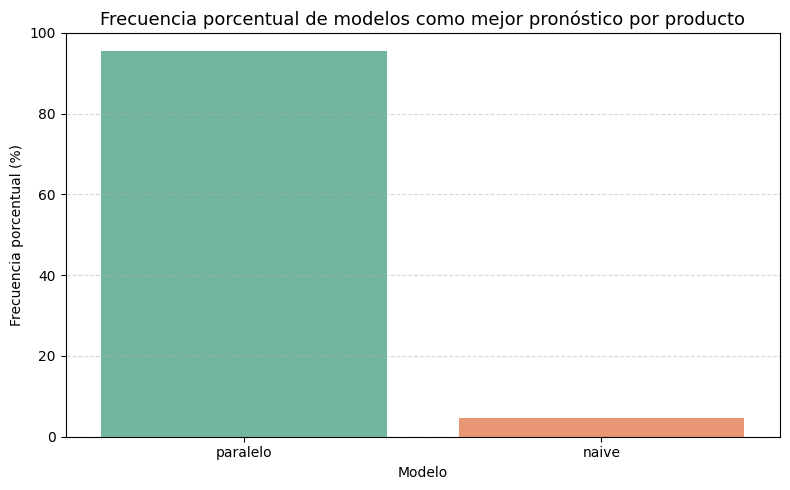

In [53]:
# -----------------------------
# GRAFICO DE BARRAS
# -----------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=frecuencia, x="modelo", y="frecuencia_porcentual", palette="Set2")
plt.title("Frecuencia porcentual de modelos como mejor pronóstico por producto", fontsize=13)
plt.ylabel("Frecuencia porcentual (%)")
plt.xlabel("Modelo")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("frecuencia_modelos_mejor_pronostico.png")
plt.show()

# 7. Impacto económico del mejor model

In [54]:
# -----------------------------
# Cargar archivos
# -----------------------------
df_mejor = pd.read_csv("/kaggle/working/mejor_pronostico_por_producto.csv")
df_naive = pd.read_csv("/kaggle/working/predicciones_naive.csv")
df_aprovisionamiento = pd.read_excel("/kaggle/input/tfm-precio-y-aprov/DatosCicloAprovisionamiento.xlsx")
df_precios = pd.read_excel("/kaggle/input/tfm-precio-y-aprov/DatosPrecioMedio.xlsx")

In [55]:
# 1. Obtener RMSE por producto del mejor modelo
resumen_mejor = df_mejor.groupby("producto").agg({
    "rmse": "mean",
    "modelo": "first"
}).reset_index()
resumen_mejor.rename(columns={"rmse": "rmse_mejor"}, inplace=True)

In [56]:
# 2. Obtener RMSE por producto del naive
rmse_naive = df_naive.groupby("producto")["rmse"].mean().reset_index()
rmse_naive.rename(columns={"rmse": "rmse_naive"}, inplace=True)

In [57]:
# 3. Calcular ciclo de aprovisionamiento
df_aprovisionamiento["aprovisionamiento"] = df_aprovisionamiento["diasEntrePedidos"] + df_aprovisionamiento["diasLeadtime"]

In [58]:
# 4. Merge de toda la información
df = pd.merge(resumen_mejor, rmse_naive, on="producto")
df = pd.merge(df, df_aprovisionamiento[["producto", "aprovisionamiento"]], on="producto")
df = pd.merge(df, df_precios[["producto", "eurPrecioMedio"]], on="producto")

In [59]:
# -----------------------------
# Cálculos de stock y económico
# -----------------------------

valor_z = 1.645  # Valor Z para 95% de confianza
porcentaje_coste = 0.05  # 5% de coste de mantenimiento

# Stock en unidades
df["udsStock_naive"] = valor_z * df["rmse_naive"] * np.sqrt(df["aprovisionamiento"])
df["udsStock_mejor"] = valor_z * df["rmse_mejor"] * np.sqrt(df["aprovisionamiento"])

# Coste del stock (5% del valor)
df["coste_udsStock_naive"] = df["udsStock_naive"] * df["eurPrecioMedio"] * porcentaje_coste
df["coste_udsStock_mejor"] = df["udsStock_mejor"] * df["eurPrecioMedio"] * porcentaje_coste

# Coste anual 
df["coste_anual_naive"] = df["coste_udsStock_naive"] * 365
df["coste_anual_mejor"] = df["coste_udsStock_mejor"] * 365

# Ahorro
df["ahorro_unidades"] = df["udsStock_naive"] - df["udsStock_mejor"]
df["ahorro_coste_stock"] = df["coste_anual_naive"] - df["coste_anual_mejor"]

In [60]:
df.head()

,producto,rmse_mejor,modelo,rmse_naive,aprovisionamiento,eurPrecioMedio,udsStock_naive,udsStock_mejor,coste_udsStock_naive,coste_udsStock_mejor,coste_anual_naive,coste_anual_mejor,ahorro_unidades,ahorro_coste_stock
0,1,6.207600,paralelo,10.176037,29,68.730000,90.145400,54.990618,309.784666,188.975258,113071.403031,68975.969039,35.154782,44095.433992
1,2,4.087119,paralelo,7.029495,29,148.330000,62.271453,36.206132,461.836229,268.522781,168570.223646,98010.815190,26.065320,70559.408456
2,3,4.895565,paralelo,5.777483,29,169.000000,51.180389,43.367835,432.474286,366.458210,157853.114225,133757.246541,7.812553,24095.867684
3,4,3.015141,paralelo,3.855135,29,0.604383,34.151087,26.709920,1.032017,0.807151,376.686112,294.610118,7.441168,82.075994
4,5,2.727181,paralelo,3.828207,29,4.553314,33.912544,24.158996,7.720724,5.500175,2818.064078,2007.563887,9.753548,810.500190


In [61]:
# -----------------------------
# Resultados agregados
# -----------------------------
total_coste_naive = df["coste_anual_naive"].sum()
total_coste_mejor = df["coste_anual_mejor"].sum()
total_ahorro = df["ahorro_coste_stock"].sum()
porcentaje_ahorro = 100 * total_ahorro / df["coste_anual_naive"].sum()

print(f"Coste total de stock naive: {total_coste_naive:.2f} €")
print(f"Coste total de stock mejor: {total_coste_mejor:.2f} €")
print(f"Ahorro económico anual estimado: {total_ahorro:.2f} €")
print(f"Porcentaje de ahorro respecto al Naive: {porcentaje_ahorro:.2f}%")

Coste total de stock naive: 16038733.42 €
Coste total de stock mejor: 10818031.83 €
Ahorro económico anual estimado: 5220701.59 €
Porcentaje de ahorro respecto al Naive: 32.55%


In [62]:
# -----------------------------
# Guardar resumen
# -----------------------------
df.to_csv("impacto_economico.csv", index=False)
print("Archivo generado.")

Archivo generado.


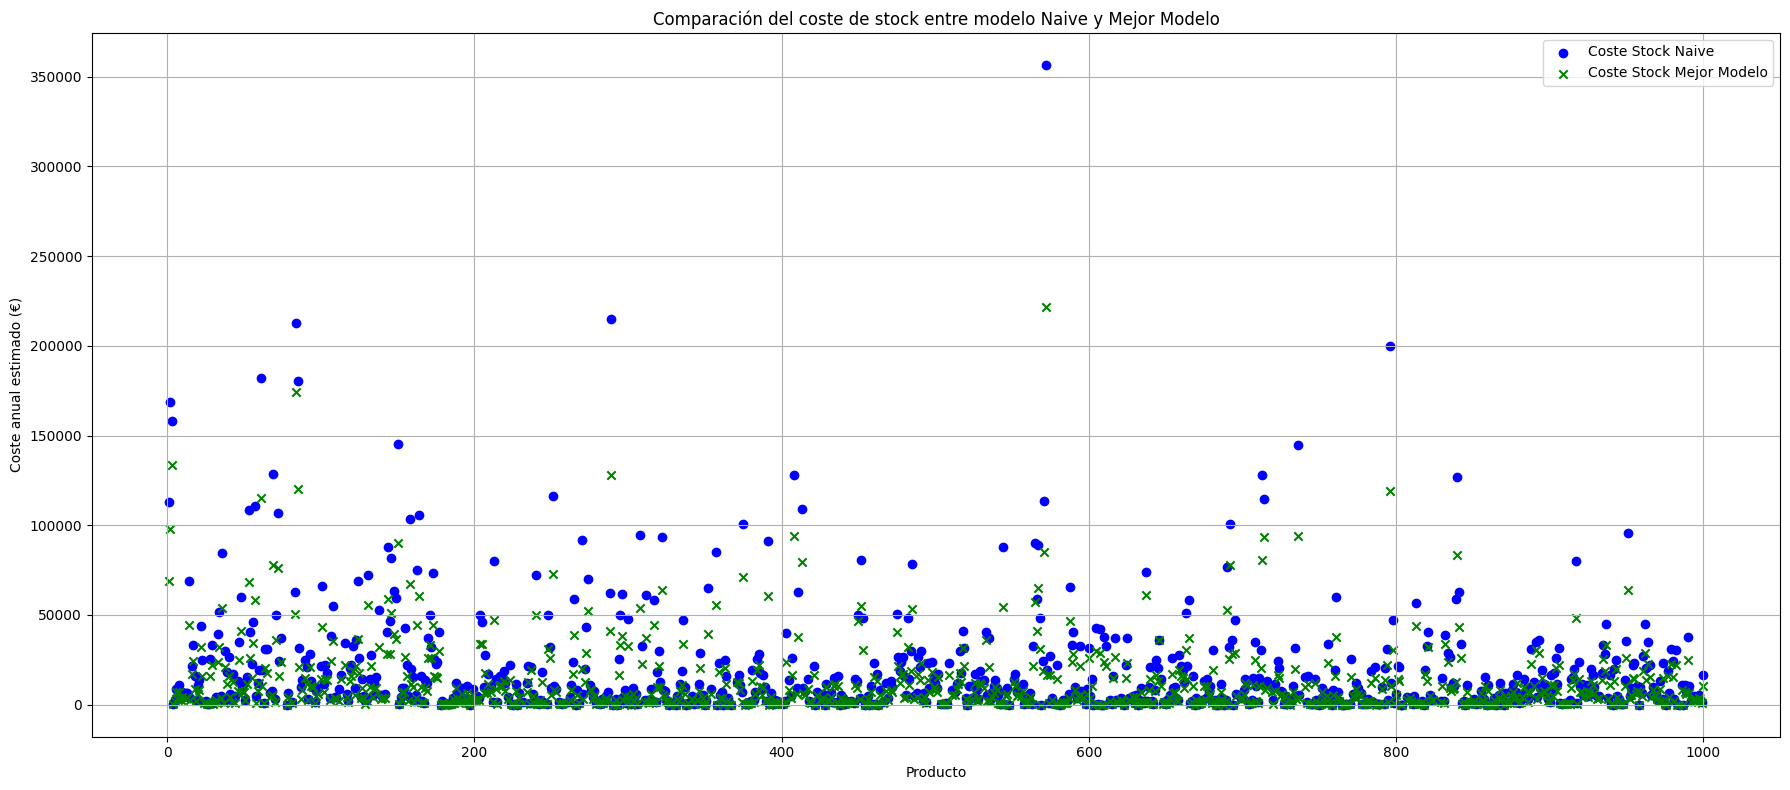

In [63]:
# -----------------------------
# Ordenar productos para el gráfico
# -----------------------------
df_sorted = df.sort_values("producto").reset_index(drop=True)

# -----------------------------
# Graficar coste_stock naive vs mejor
# -----------------------------
plt.figure(figsize=(18, 8))

# Scatter para Naive
plt.scatter(df_sorted['producto'], df_sorted['coste_anual_naive'], label='Coste Stock Naive', marker='o', color='blue')

# Scatter para Mejor Modelo
plt.scatter(df_sorted['producto'], df_sorted['coste_anual_mejor'], label='Coste Stock Mejor Modelo', marker='x', color='green')

plt.title("Comparación del coste de stock entre modelo Naive y Mejor Modelo")
plt.xlabel("Producto")
plt.ylabel("Coste anual estimado (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lineplot_coste_stock_comparativo.png")
plt.show()